## VLM to 3d distillation using wildscenes dataset


In [ ]:
!pip install awscli --q
!pip install open3d --q
!pip install ocnn --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.7/74.7 kB 1.5 MB/s eta 0:00:00


## Wildscences 2d to 3d

In [ ]:
%env AWS_ACCESS_KEY_ID=input-your-key
%env AWS_SECRET_ACCESS_KEY=input-your-key
%env AWS_ENDPOINT_URL=https://s3.data.csiro.au

## Downloading V-01 data

In [ ]:
# Creating directory
!mkdir -p /content/data/V-01

# Download only V-01 files, ignoring others
!aws s3 cp --endpoint-url https://s3.data.csiro.au --recursive s3://dapprd/000061541v003/ /content/data/V-01/ --exclude "*" --include "*V-01*" --include "*V - 01*"

In [ ]:
import os
import yaml
import pandas as pd

base_path = "/content/data/V-01/data/WildScenes"
path_2d = os.path.join(base_path, "WildScenes2d", "V-01")
path_3d = os.path.join(base_path, "WildScenes3d", "V-01")


In [ ]:
# printing the camera calibrantion
calib_path = os.path.join(path_2d, "camera_calibration.yaml")
with open(calib_path, "r") as f:
    calib = yaml.safe_load(f)

for key, val in calib.items():
  print(f"{key}: {val}")

centre-camera: {'defaults': ['default-2016x1512-camera', 'default-centre-camera'], 'intrinsics': {'type': 'OPENCV-CAMERA', 'K': [1322.75469666, 1321.88964261, 1014.8117275, 752.801443314], 'D': [-0.375544743338, 0.18170559597, 2.56096381883e-05, 0.000132368170638, -0.0484258376688]}, 'extrinsics': {'type': 'TF', 'translation': [0.0694452427858, -0.00671311927669, 0.0208717486986], 'rotation': [-0.425823882941, 0.426984260045, -0.561904677707, 0.566234576446], 'frame-id': 'slam_base_link', 'child-frame-id': 'camera0'}}


In [ ]:
# Inspecting poses structure
poses_path = os.path.join(path_2d, "poses2d.csv")
poses_df = pd.read_csv(poses_path)
print(poses_df.head(5))

                         timestamp x y z qw qx qy qz
0  2021-06-11 02:16:30.818434477 1623377790.81843...
1  2021-06-11 02:16:32.158486128 1623377792.15848...
2  2021-06-11 02:16:36.111739635 1623377796.11173...
3  2021-06-11 02:16:39.999188900 1623377799.99918...
4  2021-06-11 02:16:40.668195248 1623377800.66819...


In [ ]:
# checking for file match
img_files = sorted(os.listdir(os.path.join(path_2d, "image")))
label_files = sorted(os.listdir(os.path.join(path_2d, "indexLabel")))
cloud_files = sorted(os.listdir(path_3d))

print("First 2 images:", img_files[:2])
print("First 2 labels:", label_files[:2])
print("First 2 clouds:", cloud_files[:2])

First 2 images: ['1623377790-818434554.png', '1623377792-158486120.png']
First 2 labels: ['1623377790-818434554.png', '1623377792-158486120.png']
First 2 clouds: ['Clouds', 'Hists']


In [ ]:
import os
import yaml
import numpy as np
import pandas as pd
import cv2
import open3d as o3d
import glob
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# paths
base_path = "/content/data/V-01/data/WildScenes"
path_2d = os.path.join(base_path, "WildScenes2d", "V-01")
path_3d = os.path.join(base_path, "Fullclouds", "V-01")

# loading calibration
with open(os.path.join(path_2d, "camera_calibration.yaml"), 'r') as f:
    calib = yaml.safe_load(f)

In [ ]:
cam_data = calib['centre-camera']
K_flat = cam_data['intrinsics']['K']
fx, fy, cx, cy = K_flat
K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])

t_lidar_cam = np.array(cam_data['extrinsics']['translation'])
q_lidar_cam = np.array(cam_data['extrinsics']['rotation'])

r = R.from_quat(q_lidar_cam)  #

T_cam_lidar = np.eye(4)
T_cam_lidar[:3, :3] = r.as_matrix()
T_cam_lidar[:3, 3] = t_lidar_cam

Matching Cloud: 1623377796.111739618.ply
Matching Image: 1623377796-111739618.png

Point Cloud Bounds (X,Y,Z):
Min: [-44.92821884 -44.84458542  -9.26305008]
Max: [44.92353821 44.87805176 31.1380291 ]

Projected 325442 points -> 45691 visible points


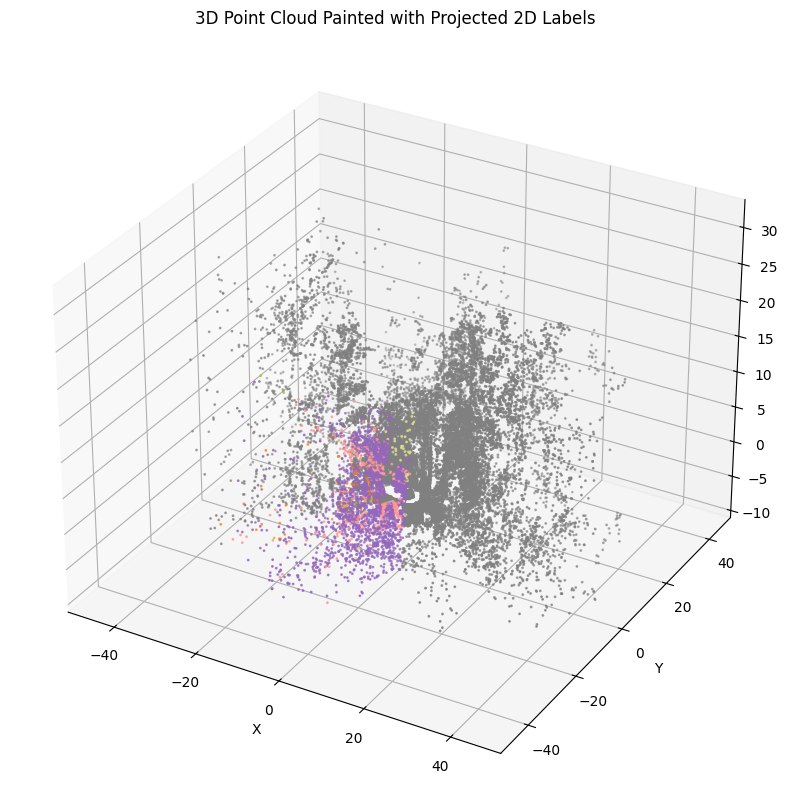

In [ ]:
# find matching files
img_files = sorted(glob.glob(os.path.join(path_2d, 'image', '*.png')))
label_files = sorted(glob.glob(os.path.join(path_2d, 'indexLabel', '*.png')))

cloud_files = sorted(glob.glob(os.path.join(path_3d, '*.ply'))) # find ply equivalent

cloud_path = cloud_files[0]
base_ts = os.path.basename(cloud_path).replace('.ply', '')
img_ts = base_ts.replace('.', '-')

img_path = os.path.join(path_2d, 'image', f"{img_ts}.png")
label_path = os.path.join(path_2d, 'indexLabel', f"{img_ts}.png")

print(f"Matching Cloud: {os.path.basename(cloud_path)}")
print(f"Matching Image: {os.path.basename(img_path)}")

# load data
img = cv2.imread(img_path)
label = cv2.imread(label_path, cv2.IMREAD_UNCHANGED)
pcd = o3d.io.read_point_cloud(cloud_path)
points = np.asarray(pcd.points)

# Check coordinate frame. min/max print
print(f"\nPoint Cloud Bounds (X,Y,Z):")
print(f"Min: {points.min(axis=0)}")
print(f"Max: {points.max(axis=0)}")

# projecting 3d to 2d
N = len(points)
points_homo = np.hstack([points, np.ones((N, 1))])

# Transform points from Lidar frame to Camera frame
points_cam = (T_cam_lidar @ points_homo.T).T[:, :3]

# Filter points in front of camera (z > 0)
front_mask = points_cam[:, 2] > 0
points_cam_front = points_cam[front_mask]

# Project to 2D pixels
pixels_homo = (K @ points_cam_front.T).T
pixels = pixels_homo[:, :2] / pixels_homo[:, 2:3]

# Filter points inside image bounds
H, W = img.shape[:2]
in_bounds = (pixels[:, 0] >= 0) & (pixels[:, 0] < W) & \
            (pixels[:, 1] >= 0) & (pixels[:, 1] < H)

pixels_valid = pixels[in_bounds].astype(int)
depths_valid = points_cam_front[in_bounds][:, 2]
valid_indices = np.where(front_mask)[0][in_bounds]

# Visibility check(z-buffer)
depth_buffer = np.full((H, W), np.inf)
pixel_indices = pixels_valid
sort_order = np.argsort(-depths_valid)
for i in sort_order:
    u, v = pixel_indices[i]
    depth_buffer[v, u] = depths_valid[i]

tolerance = 0.1 # 10cm
visible = np.zeros(len(pixels_valid), dtype=bool)
for i, (u, v) in enumerate(pixel_indices):
    if abs(depths_valid[i] - depth_buffer[v, u]) < tolerance:
        visible[i] = True

print(f"\nProjected {len(points)} points -> {visible.sum()} visible points")

# Assigning 2D labels to 3D points
labels_3d = np.full(len(points), -1) # -1 = unlabelled
visible_pixels = pixels_valid[visible]
visible_indices = valid_indices[visible]

for i, (u, v) in enumerate(visible_pixels):
    label_val = label[v, u]
    labels_3d[visible_indices[i]] = label_val

# visualizing
label_colors = plt.cm.tab20(np.linspace(0, 1, 20))[:, :3]
colors = np.full((len(points), 3), 0.5) # grey default
for i in range(len(points)):
    if labels_3d[i] >= 0:
        colors[i] = label_colors[labels_3d[i] % len(label_colors)]

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
step = max(1, len(points) // 30000)
ax.scatter(points[::step, 0], points[::step, 1], points[::step, 2], c=colors[::step], s=1)
ax.set_title('3D Point Cloud Painted with Projected 2D Labels')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.show()

In [ ]:
print(img.shape)
print(label.shape)
print(points.shape)

(1512, 2016, 3)
(1512, 2016)
(325442, 3)


In [ ]:
r

Rotation.from_matrix(array([[-0.27271692,  0.00238351,  0.96209137],
                            [-0.96208132, -0.00587431, -0.27269952],
                            [ 0.00500164, -0.99997991,  0.00389515]]))

In [ ]:
t_lidar_cam

array([ 0.06944524, -0.00671312,  0.02087175])

In [ ]:
T_cam_lidar

array([[-0.27271692,  0.00238351,  0.96209137,  0.06944524],
       [-0.96208132, -0.00587431, -0.27269952, -0.00671312],
       [ 0.00500164, -0.99997991,  0.00389515,  0.02087175],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [ ]:
# Install SAM and download weights
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

Generating masks...
Generated 56 SAM masks.


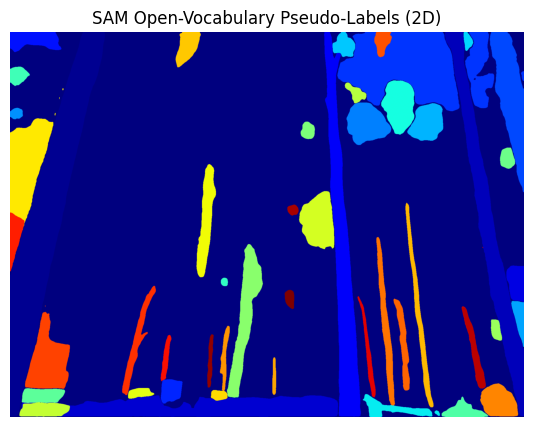

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Run SAM on the 2D Image
print("Loading SAM model (this takes a minute)...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sam = sam_model_registry["vit_h"](checkpoint="/content/sam_vit_h_4b8939.pth")
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(sam)  # it will take some time on cpu

print("Generating masks..........")
masks = mask_generator.generate(img)

# Create a Pseudo-Label Map from SAM
# SAM gives us hundreds of masks. We assign each one a unique ID to create a 2D label map.
H, W = img.shape[:2]
sam_label_map = np.zeros((H, W), dtype=np.uint8)
for i, mask_data in enumerate(masks):
    sam_label_map[mask_data['segmentation']] = i + 1  # +1 because 0 is background

print(f"Generated {len(masks)} SAM masks.")

# Visualize the SAM label map
plt.figure(figsize=(10, 5))
plt.imshow(sam_label_map, cmap='jet')
plt.title("SAM Open-Vocabulary Pseudo-Labels (2D)")
plt.axis('off')
plt.show()

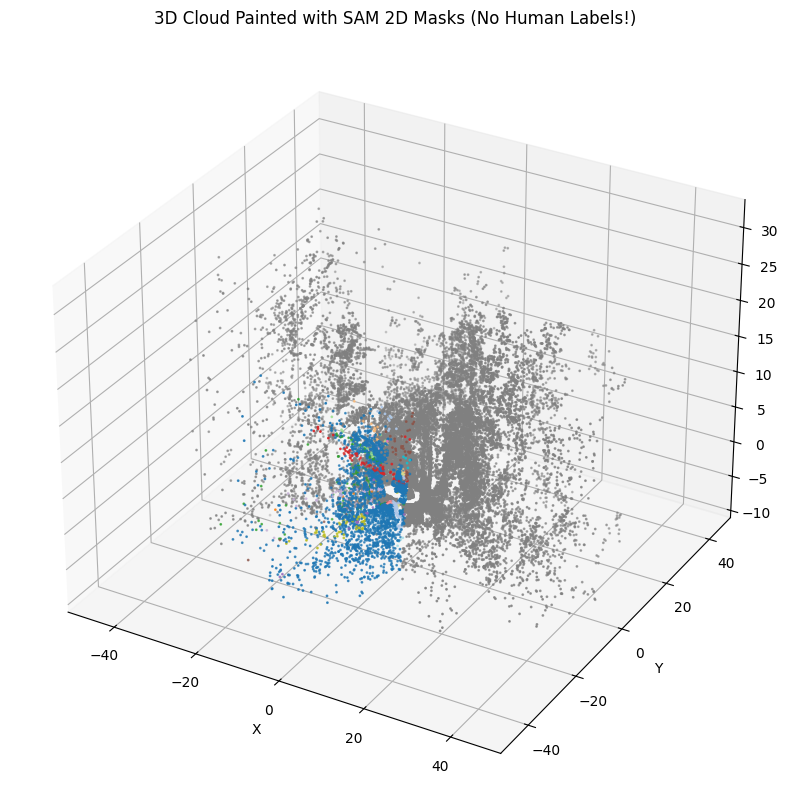

In [ ]:
# Project SAM Labels into 3D
# We reuse the exact same visibility logic, but sample from sam_label_map instead of label
labels_3d_sam = np.full(len(points), -1) # -1 = unlabelled

# We use the exact same visible_pixels and valid_indices from old cell(few cells above)
for i, (u, v) in enumerate(visible_pixels):
    label_val = sam_label_map[v, u]
    labels_3d_sam[visible_indices[i]] = label_val

# Visualize the 3D VLM-Projected Cloud
# Use a random color map for the SAM masks since they aren't semantic classes
label_colors = plt.cm.tab20(np.linspace(0, 1, 20))[:, :3]
colors_sam = np.full((len(points), 3), 0.5) # grey default
for i in range(len(points)):
    if labels_3d_sam[i] >= 0:
        # Cycle through colors based on mask ID
        colors_sam[i] = label_colors[labels_3d_sam[i] % len(label_colors)]

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
step = max(1, len(points) // 30000)
ax.scatter(points[::step, 0], points[::step, 1], points[::step, 2], c=colors_sam[::step], s=1)
ax.set_title('3D Cloud Painted with SAM 2D Masks (No Human Labels!)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.show()

## Making the code modular

In [ ]:
!pip install awscli -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [ ]:
# 1. Set your fresh credentials
%env AWS_ACCESS_KEY_ID=input_your_key
%env AWS_SECRET_ACCESS_KEY=input-your-key
%env AWS_ENDPOINT_URL=https://s3.data.csiro.au

In [ ]:
!mkdir -p /content/data/V-01
!aws s3 cp --endpoint-url https://s3.data.csiro.au --recursive s3://dapprd/000061541v003/ /content/data/V-01/ --exclude "*" --include "*V-01*" --include "*V - 01*"

Streaming output truncated to the last 5000 lines.
download: s3://dapprd/000061541v003/data/WildScenes/WildScenes2d/V-01/image/1623379083-592890257.png to data/V-01/data/WildScenes/WildScenes2d/V-01/image/1623379083-592890257.png
download: s3://dapprd/000061541v003/data/WildScenes/WildScenes2d/V-01/image/1623379085-602528879.png to data/V-01/data/WildScenes/WildScenes2d/V-01/image/1623379085-602528879.png
download: s3://dapprd/000061541v003/data/WildScenes/WildScenes2d/V-01/image/1623379088-885508470.png to data/V-01/data/WildScenes/WildScenes2d/V-01/image/1623379088-885508470.png
download: s3://dapprd/000061541v003/data/WildScenes/WildScenes2d/V-01/image/1623379087-411430752.png to data/V-01/data/WildScenes/WildScenes2d/V-01/image/1623379087-411430752.png
download: s3://dapprd/000061541v003/data/WildScenes/WildScenes2d/V-01/image/1623379094-312648893.png to data/V-01/data/WildScenes/WildScenes2d/V-01/image/1623379094-312648893.png
download: s3://dapprd/000061541v003/data/WildScenes/Wi

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git -q

  Preparing metadata (setup.py) ... done


In [ ]:
!pip install open3d --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.5 MB/s eta 0:00:00


Loading calibration and finding matching files...
Projecting 3D points to 2D camera frame...
Running Z-Buffer visibility check...
Loading SAM model...
Generating SAM masks...
Distilling 2D VLM masks into 3D geometry...
Generating plot...


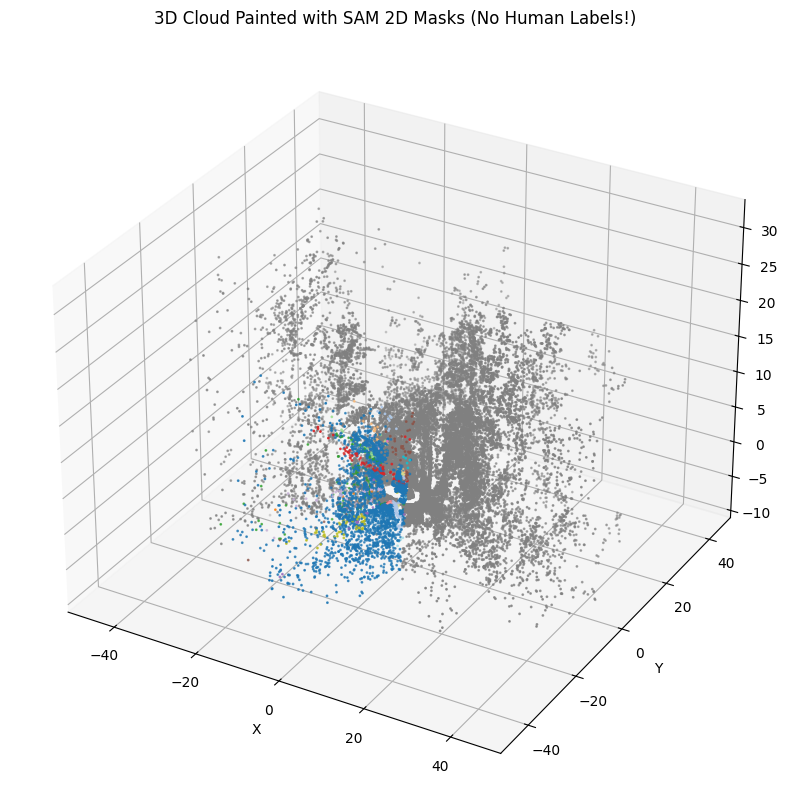

In [ ]:
import os
import yaml
import numpy as np
import cv2
import open3d as o3d
import glob
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Colab Specific Paths
BASE_PATH = "/content/data/V-01/data/WildScenes"
PATH_2D = os.path.join(BASE_PATH, "WildScenes2d", "V-01")
PATH_3D = os.path.join(BASE_PATH, "Fullclouds", "V-01")
SAM_CHECKPOINT = "/content/sam_vit_h_4b8939.pth"


Pipeline functions testing

In [ ]:

def load_calibration(calib_path):
    with open(calib_path, 'r') as f:
        calib = yaml.safe_load(f)
    cam_data = calib['centre-camera']
    K_flat = cam_data['intrinsics']['K']
    fx, fy, cx, cy = K_flat
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])
    t_lidar_cam = np.array(cam_data['extrinsics']['translation'])
    q_lidar_cam = np.array(cam_data['extrinsics']['rotation'])
    r = R.from_quat(q_lidar_cam)
    T_cam_lidar = np.eye(4)
    T_cam_lidar[:3, :3] = r.as_matrix()
    T_cam_lidar[:3, 3] = t_lidar_cam
    return K, T_cam_lidar

def find_matching_files(path_2d, path_3d):
    cloud_files = sorted(glob.glob(os.path.join(path_3d, '*.ply')))
    if not cloud_files:
        raise FileNotFoundError(f"No .ply files found in {path_3d}")
    cloud_path = cloud_files[0]
    base_ts = os.path.basename(cloud_path).replace('.ply', '')
    img_ts = base_ts.replace('.', '-')
    img_path = os.path.join(path_2d, 'image', f"{img_ts}.png")
    label_path = os.path.join(path_2d, 'indexLabel', f"{img_ts}.png")
    return cloud_path, img_path, label_path

In [ ]:
def project_3d_to_2d(points, K, T_cam_lidar, H, W):
    N = len(points)
    points_homo = np.hstack([points, np.ones((N, 1))])
    points_cam = (T_cam_lidar @ points_homo.T).T[:, :3]
    front_mask = points_cam[:, 2] > 0
    points_cam_front = points_cam[front_mask]
    pixels_homo = (K @ points_cam_front.T).T
    pixels = pixels_homo[:, :2] / pixels_homo[:, 2:3]
    in_bounds = (pixels[:, 0] >= 0) & (pixels[:, 0] < W) & \
                (pixels[:, 1] >= 0) & (pixels[:, 1] < H)
    pixels_valid = pixels[in_bounds].astype(int)
    depths_valid = points_cam_front[in_bounds][:, 2]
    valid_indices = np.where(front_mask)[0][in_bounds]
    return pixels_valid, depths_valid, valid_indices

def z_buffer_visibility(pixels_valid, depths_valid, H, W, tolerance=0.1):
    depth_buffer = np.full((H, W), np.inf)
    sort_order = np.argsort(-depths_valid)
    for i in sort_order:
        u, v = pixels_valid[i]
        depth_buffer[v, u] = depths_valid[i]
    visible = np.zeros(len(pixels_valid), dtype=bool)
    for i, (u, v) in enumerate(pixels_valid):
        if abs(depths_valid[i] - depth_buffer[v, u]) < tolerance:
            visible[i] = True
    return visible

In [ ]:
def assign_2d_labels_to_3d(points, visible_pixels, visible_indices, label_map):
    labels_3d = np.full(len(points), -1)
    for i, (u, v) in enumerate(visible_pixels):
        label_val = label_map[v, u]
        labels_3d[visible_indices[i]] = label_val
    return labels_3d

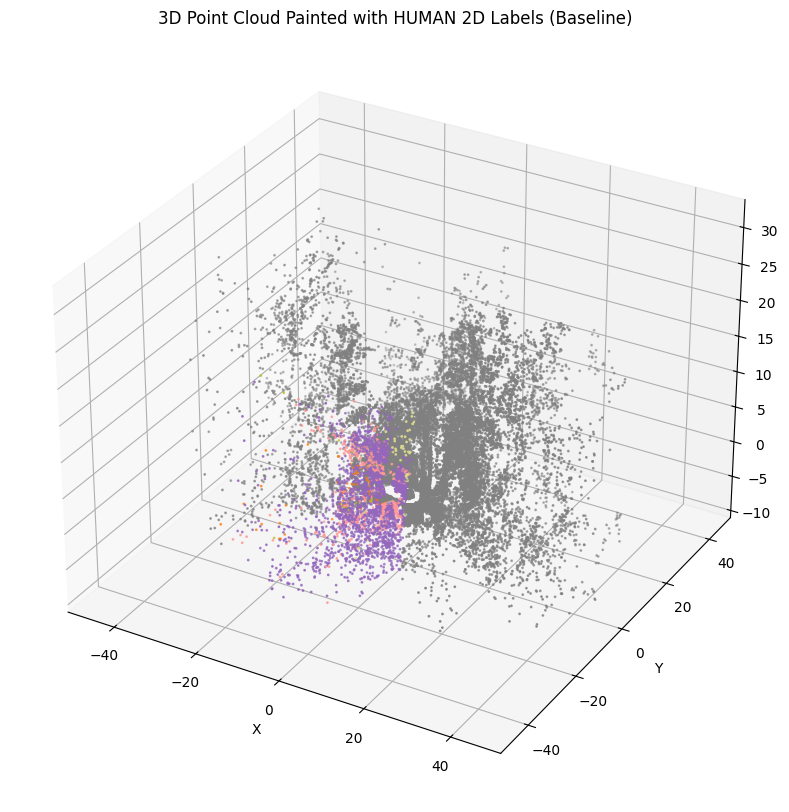

In [14]:
# Visualize the 3D Human Labels
labels_3d_human = assign_2d_labels_to_3d(points, visible_pixels, valid_indices[visible], human_label)

label_colors = plt.cm.tab20(np.linspace(0, 1, 20))[:, :3]
colors_human = np.full((len(points), 3), 0.5) # grey default
for i in range(len(points)):
    if labels_3d_human[i] >= 0:
        colors_human[i] = label_colors[labels_3d_human[i] % len(label_colors)]

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
step = max(1, len(points) // 30000)
ax.scatter(points[::step, 0], points[::step, 1], points[::step, 2], c=colors_human[::step], s=1)
ax.set_title('3D Point Cloud Painted with HUMAN 2D Labels (Baseline)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.show()

In [ ]:
# This will take some time to run, try with gpu, takes 15 minutes with cpu.

# loading the calibration and finding matching files.

calib_path = os.path.join(PATH_2D, "camera_calibration.yaml")
K, T_cam_lidar = load_calibration(calib_path)
cloud_path, img_path, label_path = find_matching_files(PATH_2D, PATH_3D)

img = cv2.imread(img_path)
human_label = cv2.imread(label_path, cv2.IMREAD_UNCHANGED)
pcd = o3d.io.read_point_cloud(cloud_path)
points = np.asarray(pcd.points)
H, W = img.shape[:2]

print("Projecting 3D points to 2D camera frame...")
pixels_valid, depths_valid, valid_indices = project_3d_to_2d(points, K, T_cam_lidar, H, W)
print("Running Z-Buffer visibility check...")
visible = z_buffer_visibility(pixels_valid, depths_valid, H, W)
visible_pixels = pixels_valid[visible]

# Run SAM
print("Loading SAM model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT)
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(sam)

print("Generating SAM masks...")
masks = mask_generator.generate(img)

sam_label_map = np.zeros((H, W), dtype=np.uint8)
for i, mask_data in enumerate(masks):
    sam_label_map[mask_data['segmentation']] = i + 1

# Distill
print("Distilling 2D VLM masks into 3D geometry...")
labels_3d_sam = assign_2d_labels_to_3d(points, visible_pixels, valid_indices[visible], sam_label_map)


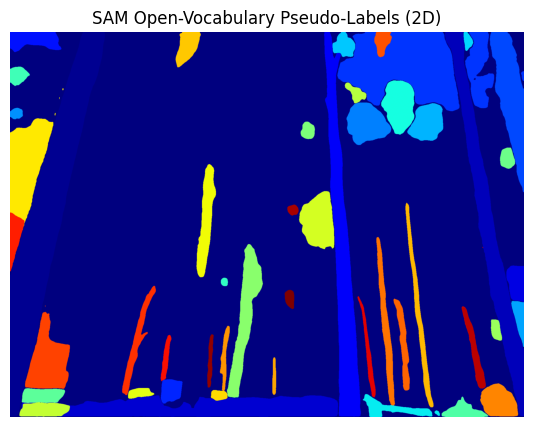

In [15]:
# Visualize the SAM 2D label map
plt.figure(figsize=(10, 5))
plt.imshow(sam_label_map, cmap='jet')
plt.title("SAM Open-Vocabulary Pseudo-Labels (2D)")
plt.axis('off')
plt.show()

Generating plot...


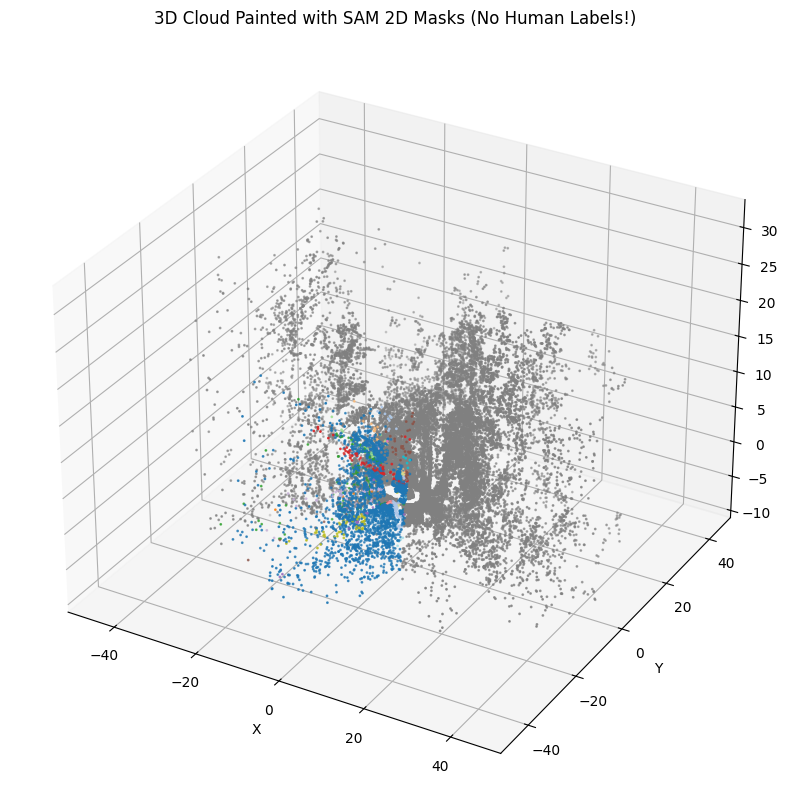

In [16]:
# Visualize
print("Generating plot...")
label_colors = plt.cm.tab20(np.linspace(0, 1, 20))[:, :3]
colors_sam = np.full((len(points), 3), 0.5)
for i in range(len(points)):
    if labels_3d_sam[i] >= 0:
        colors_sam[i] = label_colors[labels_3d_sam[i] % len(label_colors)]

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
step = max(1, len(points) // 30000)
ax.scatter(points[::step, 0], points[::step, 1], points[::step, 2], c=colors_sam[::step], s=1)
ax.set_title('3D Cloud Painted with SAM 2D Masks (No Human Labels)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.show()

end